# Evaluate model on data splits

In this notebook, we look at the performance of TCRStructMap on different data splitting strategies. We also look at the peptide channels and MHC pseudo sequence channels separately to note that the MHC channel can provide a shortcut for learning under some splitting strategies.

In [1]:
import collections
import itertools

import IPython.display as ipy_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.metrics import roc_auc_score

In [2]:
SIGNIFICANCE_LEVEL = 0.05

In [3]:
ablations = ('', 'cdrs_peptide', 'cdrs_mhc_pseudo')
data_splits = ('random', 'peptide', 'pMHC')

In [4]:
predictions = []
for data_split in data_splits:
    for ablation in ablations:
        prediction = pd.read_csv(
            f"data/processed/TCRStructMap_{ablation + '_' if ablation else ablation}predictions_on_sequences_"
            f'{data_split}_split.csv'
        )

        prediction['data_split'] = data_split
        prediction['ablation'] = ablation

        sequences = pd.read_csv(f'data/interim/sequences_{data_split}_split.csv', index_col='index')
        prediction = prediction.merge(sequences, how='left', left_on='index', right_index=True)

        prediction = prediction[prediction['fold'] == prediction['sub_model_number']].reset_index(drop=True)

        predictions.append(prediction)

predictions = pd.concat(predictions).reset_index(drop=True)

In [5]:
overall_roc_auc = predictions.groupby(['data_split', 'ablation']).apply(
    lambda group: roc_auc_score(group['label'], group['prediction']), include_groups=False
)
overall_roc_auc.name = 'roc_auc_score'

overall_roc_auc = overall_roc_auc.reindex(
    pd.MultiIndex.from_product(
        [data_splits, ablations],
        names=['data_split', 'ablation'],
    )
)

overall_roc_auc

data_split  ablation       
random                         0.876085
            cdrs_peptide       0.850001
            cdrs_mhc_pseudo    0.798126
peptide                        0.666831
            cdrs_peptide       0.528823
            cdrs_mhc_pseudo    0.627522
pMHC                           0.471265
            cdrs_peptide       0.473188
            cdrs_mhc_pseudo    0.446419
Name: roc_auc_score, dtype: float64

In [6]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 500

indices = predictions['index'].unique()
rng = np.random.default_rng(123)

samples_metric_scores = []
for sample_num in range(1, NUM_SAMPLES + 1):
    sample_indices = rng.choice(indices, SAMPLE_SIZE)

    sample = predictions[predictions['index'].isin(sample_indices)]

    for (data_split, ablation), group in sample.groupby(['data_split', 'ablation'], dropna=False):
        score = roc_auc_score(group['label'], group['prediction'])
        samples_metric_scores.append(
            {
                'sample_num': sample_num,
                'data_split': data_split,
                'ablation': ablation,
                'roc_auc_score': score,
            }
        )

samples_metric_scores = pd.DataFrame(samples_metric_scores)

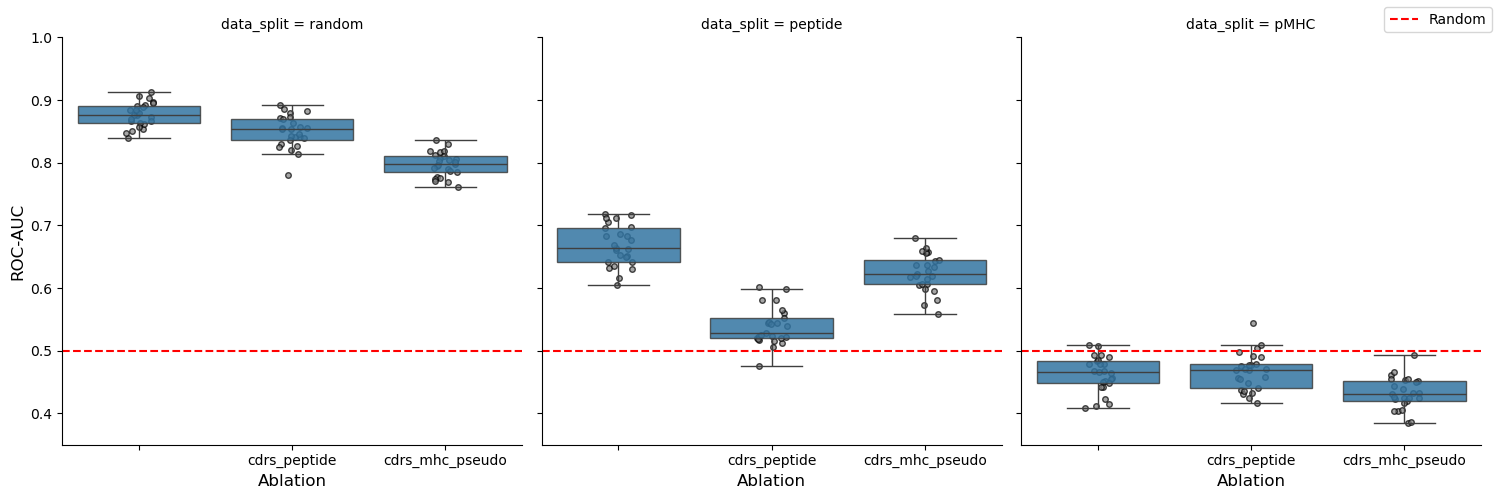

In [7]:
grid = sns.FacetGrid(samples_metric_scores, col='data_split', col_order=data_splits, sharex=False, height=5)

grid.map_dataframe(
    sns.boxplot, x='ablation', y='roc_auc_score', order=ablations, showfliers=False, boxprops={'alpha': 0.85}, zorder=1
)
grid.map_dataframe(
    sns.stripplot,
    x='ablation',
    y='roc_auc_score',
    order=ablations,
    color='grey',
    marker='o',
    size=4,
    edgecolor='black',
    linewidth=1,
    alpha=0.70,
    zorder=0,
)

grid.refline(y=0.5, color='red')
refline_handle = Line2D([0], [0], color='red', linestyle='--', label='Random')
grid.figure.legend(handles=[refline_handle], loc='upper right')

grid.set(ylim=(0.35, 1.0))
grid.set_axis_labels('Ablation', 'ROC-AUC', fontsize=12)

plt.savefig('report/figures/data_split_evaluation.svg')
plt.show()

In [9]:
metric_scores_agg = pd.concat(
    [
        overall_roc_auc,
        samples_metric_scores.groupby(['data_split', 'ablation'])['roc_auc_score']
        .agg(['std'])
        .sort_index(ascending=False),
    ],
    axis=1,
)

norm_val = stats.norm.ppf(1 - SIGNIFICANCE_LEVEL / 2)
metric_scores_agg['ci'] = metric_scores_agg.apply(
    lambda row, norm_val=norm_val: (
        row['roc_auc_score'] - norm_val * row['std'],
        row['roc_auc_score'] + norm_val * row['std'],
    ),
    axis=1,
)

metric_scores_agg = metric_scores_agg.reindex(
    pd.MultiIndex.from_product(
        [data_splits, ablations],
        names=['data_split', 'ablation'],
    )
)

metric_scores_agg

roc_auc_score       std  \
data_split ablation                                   
random                           0.876085  0.019209   
           cdrs_peptide          0.850001  0.025513   
           cdrs_mhc_pseudo       0.798126  0.019373   
peptide                          0.666831  0.032473   
           cdrs_peptide          0.528823  0.029967   
           cdrs_mhc_pseudo       0.627522  0.030187   
pMHC                             0.471265  0.028396   
           cdrs_peptide          0.473188  0.030190   
           cdrs_mhc_pseudo       0.446419  0.025306   

                                                                  ci  
data_split ablation                                                   
random                      (0.8384358432460358, 0.9137340200255891)  
           cdrs_peptide       (0.799997035128197, 0.900004409437784)  
           cdrs_mhc_pseudo  (0.7601554808072338, 0.8360967497288349)  
peptide                      (0.6031860937066418, 0.730476027153012)  
           cdrs_peptide     (0.4700886585077227, 0.5875581443302175)  
           cdrs_mhc_pseudo  (0.5683555142258928, 0.6866880340007887)  
pMHC                        (0.4156106231659526, 0.5269193794332403)  
           cdrs_peptide     (0.4140172779883049, 0.5323596448567489)  
           cdrs_mhc_pseudo   (0.3968208464401598, 0.496016998504601)

In [10]:
def calculate_differences(df: pd.DataFrame) -> pd.DataFrame:
    groups = list(df.groupby('ablation'))
    groups = sorted(groups, key=lambda item: ablations.index(item[0]))

    differences = {
        'group_name_i': [],
        'group_name_j': [],
        'difference_roc_auc': [],
    }
    for i, (group_name_i, group_i) in enumerate(groups[:-1]):
        for group_name_j, group_j in groups[i + 1 :]:
            differences['difference_roc_auc'].append(
                group_i['roc_auc_score'].iloc[0] - group_j['roc_auc_score'].iloc[0]
            )

            differences['group_name_i'].append(group_name_i)
            differences['group_name_j'].append(group_name_j)

    return pd.DataFrame(differences).set_index(['group_name_i', 'group_name_j'])

In [11]:
overall_roc_auc_difference = (
    overall_roc_auc.reset_index().groupby('data_split').apply(calculate_differences, include_groups=False)
)

samples_metric_scores_differences = (
    samples_metric_scores.groupby(['sample_num', 'data_split'])
    .apply(calculate_differences, include_groups=False)
    .groupby(['data_split', 'group_name_i', 'group_name_j'])
    .agg(['std'])
)
samples_metric_scores_differences.columns = ['_'.join(column) for column in samples_metric_scores_differences.columns]


metric_scores_difference = pd.concat([overall_roc_auc_difference, samples_metric_scores_differences], axis=1)


norm_value = stats.t.ppf((2 - SIGNIFICANCE_LEVEL) / 2, NUM_SAMPLES - 1)
metric_scores_difference['ci'] = metric_scores_difference.apply(
    lambda row, norm_value=norm_value: (
        row['difference_roc_auc'] - norm_value * row['difference_roc_auc_std'],
        row['difference_roc_auc'] + norm_value * row['difference_roc_auc_std'],
    ),
    axis=1,
)

metric_scores_difference = metric_scores_difference.sort_index(
    level='data_split', key=lambda index: index.map(data_splits.index)
)

metric_scores_difference

difference_roc_auc  \
data_split group_name_i group_name_j                          
random                  cdrs_mhc_pseudo            0.077959   
                        cdrs_peptide               0.026084   
           cdrs_peptide cdrs_mhc_pseudo            0.051875   
peptide                 cdrs_mhc_pseudo            0.039309   
                        cdrs_peptide               0.138008   
           cdrs_peptide cdrs_mhc_pseudo           -0.098698   
pMHC                    cdrs_mhc_pseudo            0.024846   
                        cdrs_peptide              -0.001923   
           cdrs_peptide cdrs_mhc_pseudo            0.026770   

                                         difference_roc_auc_std  \
data_split group_name_i group_name_j                              
random                  cdrs_mhc_pseudo                0.015854   
                        cdrs_peptide                   0.018506   
           cdrs_peptide cdrs_mhc_pseudo                0.021825   
peptide                 cdrs_mhc_pseudo                0.023201   
                        cdrs_peptide                   0.033551   
           cdrs_peptide cdrs_mhc_pseudo                0.028678   
pMHC                    cdrs_mhc_pseudo                0.019210   
                        cdrs_peptide                   0.017082   
           cdrs_peptide cdrs_mhc_pseudo                0.020420   

                                                                                    ci  
data_split group_name_i group_name_j                                                    
random                  cdrs_mhc_pseudo     (0.04523773790172663, 0.11067989483382962)  
                        cdrs_peptide      (-0.012109536811161802, 0.06427795551680573)  
           cdrs_peptide cdrs_mhc_pseudo   (0.0068309296144455495, 0.09691828441546678)  
peptide                 cdrs_mhc_pseudo   (-0.008574354582769707, 0.08719292721574193)  
                        cdrs_peptide        (0.06876112702953631, 0.20725419099217723)  
           cdrs_peptide cdrs_mhc_pseudo  (-0.15788602886921696, -0.039510716519524335)  
pMHC                    cdrs_mhc_pseudo    (-0.014800697856687466, 0.0644928555111195)  
                        cdrs_peptide      (-0.03717836784727758, 0.033331447601416604)  
           cdrs_peptide cdrs_mhc_pseudo   (-0.015375090302834737, 0.06891416820312773)

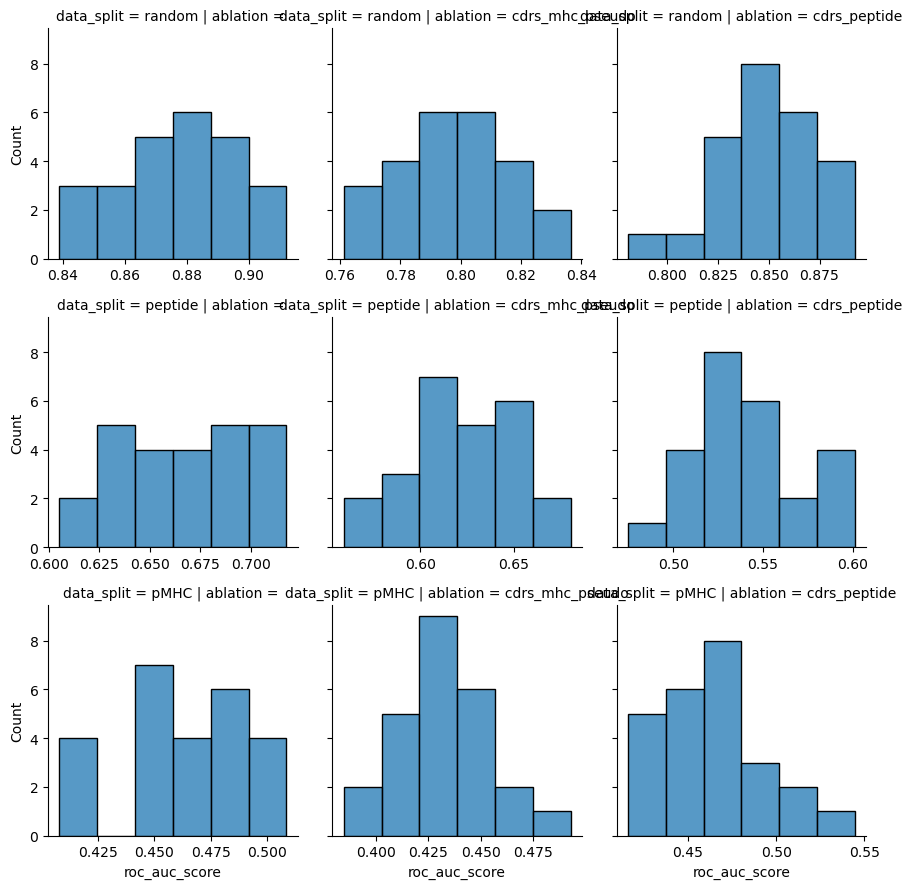

In [12]:
grid = sns.FacetGrid(samples_metric_scores, row='data_split', row_order=data_splits, col='ablation', sharex=False)
grid.map_dataframe(sns.histplot, x='roc_auc_score')
plt.show()

In [13]:
ipy_display.display(
    pg.rm_anova(samples_metric_scores, dv='roc_auc_score', within=['data_split', 'ablation'], subject='sample_num')
)

groups = list(
    samples_metric_scores.set_index('sample_num').groupby(['data_split', 'ablation'], dropna=False)['roc_auc_score']
)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

ipy_display.display(pd.DataFrame(results))

/ceph/project/koohylab/bmcmaste/miniconda3/envs/tcr-antigen-prediction/lib/python3.11/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,data_split,5.694643,2,48,2.847321,1855.028726,3.553593e-46,5.740910e-43,0.972869,0.926785
1,ablation,0.129963,2,48,0.064981,178.351481,6.005048e-23,3.380594e-21,0.450052,0.915193
2,data_split * ablation,0.185805,4,96,0.046451,227.685247,4.534962e-48,8.507024e-22,0.539167,0.425243


,group1,group2,stat,p_val,signficant
0,"(pMHC, )","(pMHC, cdrs_mhc_pseudo)",3.0,2.980232e-07,True
1,"(pMHC, )","(pMHC, cdrs_peptide)",127.0,3.525196e-01,False
2,"(pMHC, )","(peptide, )",0.0,5.960464e-08,True
3,"(pMHC, )","(peptide, cdrs_mhc_pseudo)",0.0,5.960464e-08,True
4,"(pMHC, )","(peptide, cdrs_peptide)",0.0,5.960464e-08,True
5,"(pMHC, )","(random, )",0.0,5.960464e-08,True
6,"(pMHC, )","(random, cdrs_mhc_pseudo)",0.0,5.960464e-08,True
7,"(pMHC, )","(random, cdrs_peptide)",0.0,5.960464e-08,True
8,"(pMHC, cdrs_mhc_pseudo)","(pMHC, cdrs_peptide)",0.0,5.960464e-08,True
9,"(pMHC, cdrs_mhc_pseudo)","(peptide, )",0.0,5.960464e-08,True
